In [ ]:
import os
from sklearn.pipeline import Pipeline
from model_class.feature_builder_clean_v2 import FeatureBuilder
from model_class.feature_builder_transformer import FeatureBuilderTransformer
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve


### 1. Import data

In [ ]:
# Get the current directory
current_directory = os.getcwd()
    
# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_training_data.csv"
df_train = pd.read_csv(file, header=0)
y_train = df_train['evil']
X_train = df_train.drop(columns=['sus', 'evil'])

# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_testing_data.csv"
df_test = pd.read_csv(file, header=0)
y_test = df_test['evil']
X_test = df_test.drop(columns=['sus', 'evil'])

# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_validation_data.csv"
df_validation = pd.read_csv(file, header=0)
y_validation = df_validation['evil']
X_validation = df_validation.drop(columns=['sus', 'evil'])

In [ ]:

def evaluate_model(y_true, y_pred, dataset_type="Dataset"):
    # Returns -1 for outliers and 1 for inliers.
    # change -1 to 0:
    y_pred = np.where(y_pred == -1, 1, 0)

    # Get unique values and their counts in y_true
    unique_values, counts = np.unique(y_true, return_counts=True)
    print(f"y_true_{dataset_type} Unique values: {unique_values}")
    print(f"y_true_{dataset_type} Counts of each value: {counts}")

    # Get unique values and their counts in y_pred
    unique_values, counts = np.unique(y_pred, return_counts=True)
    print(f"y_pred_{dataset_type} Unique values: {unique_values}")
    print(f"y_pred_{dataset_type} Counts of each value: {counts}")

     # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Inlier", "Outlier"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {dataset_type}')
    plt.show()

    # ROC AUC Score
    roc_auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred)

    print(f"False Positive Rate: {fpr}")
    print(f"True Positive Rate: {tpr}")


    if dataset_type == "Test Dataset":
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic for {dataset_type}')
        plt.legend(loc="lower right")
        plt.show()

### 2. build features

In [ ]:
count_cols = [
    "processId_eventId_past_count",
    "processName_past_count", # could be droped
    "processId_past_count",
    "threadId_past_count",
    "eventId_past_count",
    "userId_past_count",
    "parentProcessId_past_count", # could be droped
    "mountNamespace_past_count", # could be droped
]

# could be droped entirely
rarity_cols = [
    "processId_eventId_rarity",
    "processId_rarity",
    "processName_rarity",
    "threadId_rarity",
    "eventId_rarity",
    "userId_rarity",
    "parentProcessId_rarity",
    "mountNamespace_rarity",
]

first_seen_cols = [
    "processId_eventId_is_first_seen",
    "processId_is_first_seen",
    "processName_is_first_seen", # could be droped
    "threadId_is_first_seen",
    "eventId_is_first_seen",
    "userId_is_first_seen", # could be droped
    "parentProcessId_is_first_seen",
    "mountNamespace_is_first_seen", # could be droped
]

scale_cols = [
    "stackAddresses_len",
    "stackAddresses_unique_ratio",
    "child_process_spawn_rate_so_far", # could be droped
]

binary_cols = [
    "userId_binary",
    "parentUserId_binary",
]

other_cols = [
    "argsNum",
    "returnValue",
    "returnValue_is_error",
    "args_has_path",
]


preprocessor = ColumnTransformer(
    transformers=[
        ("count", "passthrough", count_cols),
        ("rarity", "passthrough", rarity_cols),
        ("first_seen", "passthrough", first_seen_cols),
        ("scale_other", "passthrough", scale_cols),
        ("binary", "passthrough", binary_cols),
        ("other", "passthrough", other_cols),
    ]
)

1. Isolation Forest

In [ ]:
model = Pipeline([
    ("features", FeatureBuilderTransformer(FeatureBuilder(), return_numpy=False)),
    ("scaler", preprocessor),
    ("iforest", IsolationForest(
            n_estimators=100,
            contamination="auto",
            max_features=0.7,
            random_state=2000
        ))
])


In [ ]:
# Perform fit on X _train and returns labels for y_pred.
print("Fitting model using training data...")
y_pred_train = model.fit_predict(X_train)

In [ ]:
# Perform fit on X _train and returns labels for y_pred.
print("Predict on validation data...")
y_pred_validation= model.predict(X_validation)

# Perform fit on X _train and returns labels for y_pred.
print("Predict on test data...")
y_pred_test = model.predict(X_test)

### Model Evaluation

y_true_Training Dataset Unique values: [0]
y_true_Training Dataset Counts of each value: [763144]
y_pred_Training Dataset Unique values: [0 1]
y_pred_Training Dataset Counts of each value: [681504  81640]
[[681504  81640]
 [     0      0]]


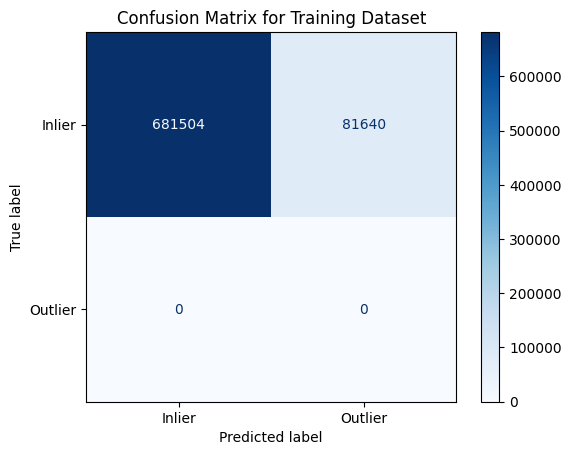

False Positive Rate: [0.        0.1069785 1.       ]
True Positive Rate: [nan nan nan]
y_true_Validation Dataset Unique values: [0]
y_true_Validation Dataset Counts of each value: [188967]
y_pred_Validation Dataset Unique values: [0 1]
y_pred_Validation Dataset Counts of each value: [164451  24516]
[[164451  24516]
 [     0      0]]


/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


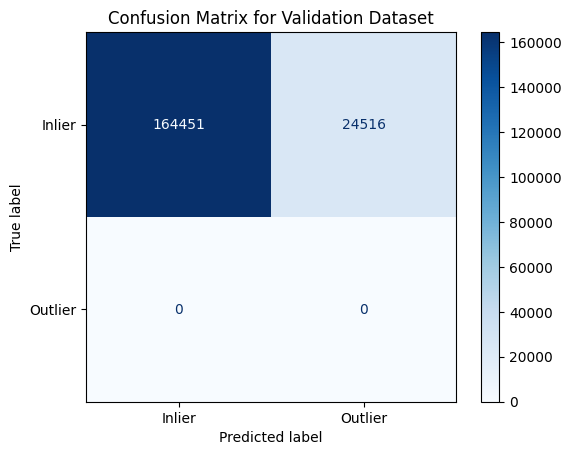

False Positive Rate: [0.         0.12973694 1.        ]
True Positive Rate: [nan nan nan]
y_true_Test Dataset Unique values: [0 1]
y_true_Test Dataset Counts of each value: [ 30535 158432]
y_pred_Test Dataset Unique values: [0 1]
y_pred_Test Dataset Counts of each value: [ 22450 166517]
[[ 21300   9235]
 [  1150 157282]]


/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


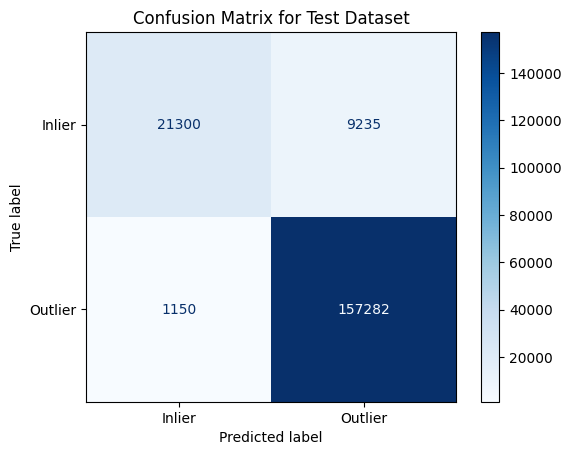

False Positive Rate: [0.         0.30243982 1.        ]
True Positive Rate: [0.         0.99274137 1.        ]


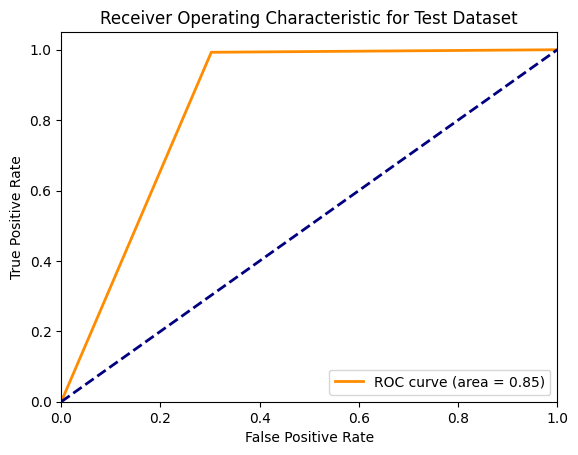

In [ ]:
evaluate_model(y_train, y_pred_train, dataset_type="Training Dataset")
evaluate_model(y_validation, y_pred_validation, dataset_type="Validation Dataset")
evaluate_model(y_test, y_pred_test, dataset_type="Test Dataset")

188967 rows before feature engineering
188967 rows after merging parent process info
188967 rows after frequency encoding
188967 Null value counts after imputation
parent_timestamp null value count: 8925
188967 rows after processing parent and child process info and relationship
188967 rows after processing stackAddresses info
188967 rows after processing arg info


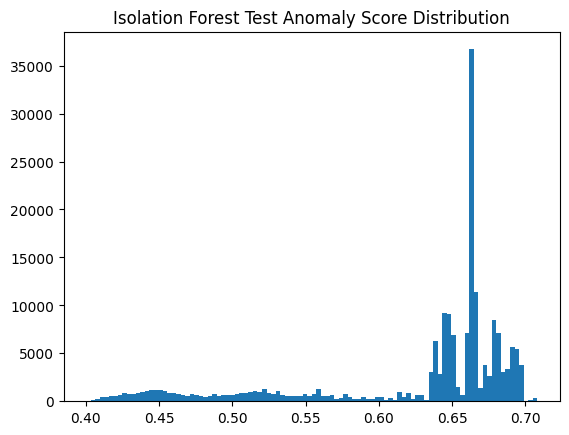

In [11]:
anomaly_scores = model.score_samples(X_test)

anomaly_scores = -anomaly_scores  # Invert scores so that higher values indicate more anomalous instances
plt.hist(anomaly_scores, bins=100)
plt.title("Isolation Forest Test Anomaly Score Distribution")
plt.show()